# Counting Arnold's Meanders in Python

### A Python companion to *Counting Arnold's Meanders with Verified Algorithms*

In 1988 Vladimir Arnold asked: in how many ways can a river cross a straight road $n$ times? The
river comes in from the south, crosses the road $n$ times without ever crossing itself, and
leaves to the east. The answers start $1, 1, 1, 2, 3, 8, 14, 42, 81, 262, \ldots$ (OEIS
A005316), and no formula is known.

The paper ([First Pair](https://firstpair.org/books/arnold-meanders/)) defines these numbers in
the Lean proof assistant and proves two fast algorithms correct. This notebook teaches Python by
building the same algorithms from scratch: the definition by brute force, the search with its
parity rule, and the transfer matrix, run first on one core and then on all of them. It assumes
no Python.

**How the notebook teaches.** Every Python feature is explained once, in a text cell, before the
first code cell that uses it, and then used freely. Each function is defined once. The index at
the end lists every feature with the section that introduces it.

**Python is not Lean.** In Lean, the fast algorithms are *proved* equal to the definition, for
every $n$. In Python we can only *test* them: we check them against each other, and against the
values that Lean's kernel has certified. Those values are copied into Section 4.

**Running it.** Any Python 3.10 or later runs Sections 1 to 8; Section 9 also needs Matplotlib.
Run the cells in order from the top.

## Contents

1. Python as a calculator
2. Crossing chords
3. A river is a permutation
4. Checking what we cannot prove
5. Closed meanders
6. A search with a parity rule
7. The transfer matrix
8. All cores at once
9. Pictures and growth
10. Index of Python features

## 1. Python as a calculator

A code cell holds Python *statements*, run from top to bottom. If the last line is an
*expression*, Jupyter shows its value. Text after `#` is a comment.

**Numbers.** Python integers have no size limit, which matters here: the number of meanders
with 55 crossings has 26 digits. `**` is a power, `//` divides and rounds down, and `%` is the
remainder. `/` always gives a floating-point number.

In [1]:
2 + 3 * 4

14

In [2]:
2 ** 100

1267650600228229401496703205376

**Variables, tuples and `print`.** `name = value` stores a value under a name. A comma-separated
list of values, usually in parentheses, is a *tuple*. `print(...)` writes its arguments as a
line. An *f-string*, `f"... {expr} ..."`, inserts the values of expressions into text.

In [3]:
q, r = 17 // 5, 17 % 5
print(q, r, 17 / 5)
print(f"17 = 5 * {q} + {r}")

3 2 3.4
17 = 5 * 3 + 2


The first line also shows *unpacking*: a tuple of names on the left takes the values of a tuple
on the right, in order.

**Truth values.** Comparisons give `True` or `False`, the two values of type `bool`. `==` tests
equality and `!=` inequality. `and`, `or` and `not` combine truth values. A `bool` is also a
number: `True` counts as `1` and `False` as `0`, which we use to count things.

In [4]:
print(3 < 5, 3 == 5, 3 != 5, not 3 < 5)
print(True + True + False)

True False True False
2


## 2. Crossing chords

Draw the road as a horizontal line and number its bridges $0, 1, \ldots, n-1$ from west to
east. Between two consecutive crossings, the river runs along an *arc* in one half-plane, below
the road or above it, and the arcs alternate sides. Two arcs on the same side are like two
chords of a disk: they cross exactly when their endpoints alternate along the road. So a river
is a meander exactly when no two arcs on the same side alternate.

**Functions.** `def name(a, b):` starts a function definition, and the indented lines below it
are its *body*. Indentation is part of Python's syntax: it marks which lines belong together.
`return value` ends the function with a result. A string literal on the first line of the body
is the function's *docstring*, its documentation.

**Chained comparisons.** `min(a, b)` and `max(a, b)` are the smaller and the larger argument.
`lo < c < hi` means `lo < c and c < hi`. Comparing two truth values
with `!=` is *exclusive or*: true when exactly one of them holds.

`interleave(a, b, c, d)` says that the chords $\{a, b\}$ and $\{c, d\}$ alternate: exactly one
of $c$, $d$ lies strictly between $a$ and $b$. This is the same condition as `Interleave` in
the Lean library.

In [5]:
def interleave(a, b, c, d):
    """True when the chords {a, b} and {c, d} cross: exactly one of c, d lies inside (a, b)."""
    lo, hi = min(a, b), max(a, b)
    return (lo < c < hi) != (lo < d < hi)


print(interleave(0, 2, 1, 3), interleave(0, 3, 1, 2))

True False


### No two arcs on one side cross

A river visits boundary points $P_0, P_1, P_2, \ldots$, and arc $k$ joins $P_k$ to $P_{k+1}$.
Arcs $j$ and $k$ lie on the same side exactly when $j$ and $k$ have the same parity.

**Lists and ranges.** `[0, 2, 1, 3]` is a *list*, a sequence that can grow and change. `P[k]`
is its entry at position `k`, counting from `0`, and `len(P)` its length. `range(n)` stands for
the numbers $0, 1, \ldots, n-1$.

**Generator expressions and `all`.** `(f(x) for x in s if c(x))` produces the values `f(x)` for
the `x` in `s` that pass the test `c(x)`, one at a time, without building a list. Several `for`
clauses nest, left to right. `all(...)` is `True` when every produced value is true. Inside a
function call the extra parentheses can be dropped.

`no_cross(P, L)` checks the first `L` arcs of the path `P` by comparing every pair of arcs on the
same side, as the Lean definition `NoCross` states it.

In [6]:
def no_cross(P, L):
    """No two of the arcs 0, ..., L-1 of the path P on the same side of the road cross."""
    return all(not interleave(P[j], P[j + 1], P[k], P[k + 1])
               for k in range(L) for j in range(k) if j % 2 == k % 2)


print(no_cross([0, 1, 2, 3], 3), no_cross([0, 2, 1, 3], 3))

True False


The first path's same-side arcs $\{0,1\}$ and $\{2,3\}$ are disjoint; the second's,
$\{0,2\}$ and $\{1,3\}$, cross.

## 3. A river is a permutation

A meander is determined by the order in which the river crosses the bridges: its $i$-th
crossing is at bridge $\sigma(i)$, for a permutation $\sigma$ of $0, \ldots, n-1$. The two ends
of the river go off to infinity, and we treat them as two more boundary points east of every
bridge: the east end, point $n$, and the south end, point $n+1$. (Compactify each half-plane to
a disk, and the road plus infinity becomes its boundary.) The path of the river is then
$$n+1,\ \sigma(0),\ \sigma(1),\ \ldots,\ \sigma(n-1),\ n,$$
with $n + 1$ arcs; the even arcs lie below the road and the odd ones above.

**Unpacking into a list.** Inside a list display, `*s` inserts all the values of `s`. So
`[n + 1, *sigma, n]` is the path.

In [7]:
def path(sigma):
    """The boundary points visited by the river with crossing order sigma."""
    n = len(sigma)
    return [n + 1, *sigma, n]


def is_meander(sigma):
    """The crossing order sigma describes a river that never crosses itself."""
    return no_cross(path(sigma), len(sigma) + 1)


print(path((0, 1, 2)), is_meander((0, 1, 2)), is_meander((1, 0, 2)))

[4, 0, 1, 2, 3] True False


**Modules and `import`.** Python's standard library is divided into *modules*. `import
itertools` loads one, and its contents are reached as `itertools.name`.
`itertools.permutations(s)` produces every ordering of `s`, each as a tuple.

**Summing truth values.** Since `True` counts as `1`, `sum(test(x) for x in s)` counts the `x`
that pass the test.

`open_meander_count(n)` is the definition, word for word: the number of permutations that
describe a meander. Like Lean's `openMeanderCount`, it is the specification that everything
faster must agree with, and it looks at all $n!$ orderings.

In [8]:
import itertools


def open_meander_count(n):
    """Arnold's number by brute force: test every crossing order."""
    return sum(is_meander(s) for s in itertools.permutations(range(n)))

**List comprehensions.** `[f(x) for x in s]` builds the list of the values `f(x)`. It is a
generator expression in square brackets.

In [9]:
[open_meander_count(n) for n in range(9)]

[1, 1, 1, 2, 3, 8, 14, 42, 81]

## 4. Checking what we cannot prove

The Lean library proves facts for every $n$: there is at least one meander and at most $n!$,
and its fast counters agree with the definition. Python can only check such facts for the
values we try. Checks are still worth writing down, because they catch mistakes, and here they
can be compared with values that Lean has certified.

**`assert`.** `assert condition, message` does nothing if `condition` is true, and stops the
program with the message if it is false. A notebook that runs to the end has passed all its
assertions.

**`for` loops and the `math` module.** `for x in s:` followed by an indented block runs the
block once for each value in `s`. `range(a, b)` counts from `a` up to `b - 1`. `math.factorial(n)`
is $n!$.

The river that zig-zags straight east, `(0, 1, ..., n-1)`, is always a meander, which is how
Lean proves there is at least one. `tuple(range(n))` turns the range into a tuple.

In [10]:
import math

for n in range(9):
    count = open_meander_count(n)
    assert is_meander(tuple(range(n))), n
    assert 1 <= count <= math.factorial(n), n
print("checked n = 0, ..., 8")

checked n = 0, ..., 8


The values below are certified in Lean. Those up to $n = 13$ were checked by Lean's kernel, and
those up to $n = 24$ by Lean's compiled code (`Arnold.openMeanderCount_values` and
`Arnold.openMeanderCount_values_native`). We name the list in capitals, the Python convention
for a constant.

**Slices.** `s[a:b]` is the part of a list (or tuple, or string) from position `a` up to `b - 1`.
A missing `a` means the start, and a missing `b` means the end, so `LEAN_VALUES[:9]` is the
first nine values.

In [11]:
LEAN_VALUES = [1, 1, 1, 2, 3, 8, 14, 42, 81, 262, 538, 1828, 3926, 13820, 30694, 110954,
               252939, 933458, 2172830, 8152860, 19304190, 73424650, 176343390, 678390116,
               1649008456]

assert [open_meander_count(n) for n in range(9)] == LEAN_VALUES[:9]

## 5. Closed meanders

A *closed* meander is a loop crossing the road $2n$ times. To count each loop once, start at the
westmost bridge $0$ and leave it upward. The loop visits bridges
$\sigma(0) = 0, \sigma(1), \ldots, \sigma(2n-1)$, and arc $k$ joins $\sigma(k)$ to
$\sigma(k+1)$, with positions taken modulo $2n$, so the last arc returns to bridge $0$.

**Tuples of a computed length.** `(0, *rest)` is the tuple `rest` with `0` in front.

In [12]:
def is_closed_meander(sigma):
    """sigma starts at bridge 0 and no two arcs of the loop on one side cross."""
    m = len(sigma)
    loop = [sigma[k % m] for k in range(m + 1)]
    return sigma[0] == 0 and no_cross(loop, m)


def closed_meanders(n):
    """All closed meanders of order n, as crossing orders starting at 0."""
    return [(0, *rest) for rest in itertools.permutations(range(1, 2 * n))
            if is_closed_meander((0, *rest))]


[len(closed_meanders(n)) for n in range(1, 5)]

[1, 2, 8, 42]

The counts $1, 2, 8, 42$ are the open counts for $1, 3, 5, 7$ crossings. Lean proves that this
holds for every $n$: delete bridge $0$ from a closed meander, so that its two arcs run off to
infinity in the west, then turn the picture through $180°$. The result is an open meander with
$2n - 1$ crossings. In the other direction, an open meander $\tau$ with $2n - 1$ crossings
becomes the closed meander $0, 2n - 1 - \tau(0), 2n - 1 - \tau(1), \ldots$ (Lean's `closeUp`).

**Sets.** A *set* holds values without order or repetition. `{f(x) for x in s}` is a set
comprehension, and two sets are equal when they have the same elements. `set(s)` makes a set
from any collection. For tuples, `+` concatenates.

We check the bijection itself, not just the counts: turning every open meander with $2n - 1$
crossings into a loop gives exactly the closed meanders of order $n$.

In [13]:
def close_up(tau):
    """Turn an open meander with 2n-1 crossings into a closed one with 2n (Lean's closeUp)."""
    return (0,) + tuple(len(tau) - t for t in tau)


for n in range(1, 5):
    opens = [t for t in itertools.permutations(range(2 * n - 1)) if is_meander(t)]
    assert {close_up(t) for t in opens} == set(closed_meanders(n))
print("close_up is a bijection for n = 1, ..., 4")

close_up is a bijection for n = 1, ..., 4


## 6. A search with a parity rule

Brute force looks at all $n!$ orders. A search builds the order one bridge at a time and
abandons a partial order as soon as it cannot be finished. The first test: the newest arc must
not cross an earlier arc on its side. The second is a rule from topology.

**The parity rule.** Take an arc $j$ already drawn, on side $s$, with ends $a < b$. Every later
arc on side $s$ has both ends inside $(a, b)$ or both outside, since it may not cross arc $j$.
So the side-$s$ arc ends still to come inside $(a, b)$ pair up, and there is an even number of
them. They are: every unvisited bridge inside $(a, b)$, since each bridge eventually gets one
arc on each side; the current point, if the next arc is on side $s$; and the east end $n$, if
the final arc $n$ is on side $s$. If the count is odd, the partial river cannot be finished.
Lean proves the rule sound (`Arnold.parityOK_of_noCross`); here we watch its effect.

**Nested functions and closures.** A function defined inside another can read the outer
function's variables; it is a *closure* over them. To *assign* to an outer variable, the inner
function must declare it `nonlocal`. A function may call itself: this is *recursion*.

**Changing lists and sets.** `order.append(x)` adds `x` at the end of the list and
`order.pop()` removes the last entry; `unused.add(x)` and `unused.remove(x)` do the same for a
set. Adding and then undoing is how a search explores a branch and comes back. `sorted(s)` is a
sorted list of the values in `s`. `x if c else y` is a conditional expression.

**`if`, `elif` and defaults.** `if c:` runs its block when `c` is true; `else:` runs otherwise.
In `def search(n, parity=True)` the parameter `parity` has a default value, used when the caller
leaves it out. A function can return a tuple, which the caller unpacks. `x += 1` is short for
`x = x + 1`. In a test, an empty collection counts as false, so `not unused` is true when no
bridges are left.

`search(n)` returns the number of meanders and the number of partial rivers it visited.

In [14]:
def search(n, parity=True):
    """Count meanders with n crossings by depth-first search; also count the nodes visited."""
    order, unused = [], set(range(n))
    nodes = 0

    def point(k):  # point k of the path: south end, the bridges so far, then the east end
        if k == 0:
            return n + 1
        return order[k - 1] if k - 1 < len(order) else n

    def inside(j, x):  # x lies strictly inside arc j
        a, b = point(j), point(j + 1)
        return min(a, b) < x < max(a, b)

    def step_ok(t):  # arc t crosses no earlier arc on its side
        c, d = point(t), point(t + 1)
        return all(not interleave(point(j), point(j + 1), c, d)
                   for j in range(t) if j % 2 == t % 2)

    def parity_ok():  # every drawn arc encloses an even number of future ends on its side
        t = len(order)
        for j in range(t):
            ends = sum(inside(j, x) for x in unused)
            ends += t % 2 == j % 2 and inside(j, point(t))
            ends += n % 2 == j % 2 and inside(j, n)
            if ends % 2 == 1:
                return False
        return True

    def go():
        nonlocal nodes
        nodes += 1
        if not unused:  # all bridges used: check the final arc to the east end
            return 1 if step_ok(n) else 0
        total = 0
        for x in sorted(unused):
            order.append(x)
            unused.remove(x)
            if step_ok(len(order) - 1) and (not parity or parity_ok()):
                total += go()
            unused.add(x)
            order.pop()
        return total

    return go(), nodes

**Timing.** `time.perf_counter()` reads a clock in seconds; the difference of two readings is
the time between them. In a format specification, `{nodes:,}` groups digits with commas and
`{x:.1f}` shows one decimal.

In [15]:
import time

for parity in (False, True):
    start = time.perf_counter()
    count, nodes = search(11, parity)
    print(f"parity={parity}: {count} meanders, {nodes:,} partial rivers, "
          f"{time.perf_counter() - start:.1f} s")

parity=False: 1828 meanders, 322,080 partial rivers, 4.2 s


parity=True: 1828 meanders, 14,471 partial rivers, 0.8 s


The parity rule cuts the partial rivers at eleven crossings from 322,080 to 14,471, the figures
in the paper. Indexing a call's result, `search(n)[0]`, takes the first value of the returned
tuple.

In [16]:
assert [search(n)[0] for n in range(14)] == LEAN_VALUES[:14]

## 7. The transfer matrix

The search follows the river. The transfer matrix scans the road instead, from west to east:
the bridges $0, \ldots, m-1$, then the east end $E = m$, which has one arc, on side
$m \bmod 2$. (The south end $S = m + 1$, with its one arc below, comes last and needs no step.)
At each point and on each side, the point either *opens* a new arc or *closes* an open one. Arcs
on one side never cross, so the open arcs on each side form a stack, and a point always closes
the top one. The machine counts all ways to make these choices that trace a single river.

**The state.** Cut the plane just east of the current point. The river west of the cut falls
into pieces, each joining two open arcs, or one open arc and the east end once $E$ has been
passed. Read the open arcs along the cut from top to bottom: the arcs above the road from the
outermost in, then the arcs below from the innermost out. The pieces lie west of the cut and
never cross, so they pair up the arcs like brackets. A state is therefore a *word* over `(`, `)`
and at most one `E` (an arc whose piece leads to the east end), together with `h`, the number of
arcs above the road. This is the encoding of the Rust and OxCaml programs; the Lean machine
stores the same information as two stacks of references.

**Strings.** A string is a sequence of characters: `word[i]` is one character, `word[a:b]` a
slice, `+` concatenates, and `len(word)` is its length. Strings cannot be changed in place. To
edit one, convert it to a list of characters with `list(word)`, change the list, and join it
back with `"".join(chars)`. `del chars[i]` removes an entry from a list.

**`while`.** `while c:` repeats its block as long as `c` is true; `while True:` repeats until a
`return` (or `break`) leaves it.

`partner(word, i)` finds the bracket matched with the one at position `i`, scanning right from
an opening bracket or left from a closing one, and skipping the `E`.

In [17]:
def partner(word, i):
    """Position of the bracket matched with word[i]."""
    step = 1 if word[i] == "(" else -1
    depth, j = 0, i + step
    while True:
        if word[j] == word[i]:
            depth += 1
        elif word[j] != "E":
            if depth == 0:
                return j
            depth -= 1
        j += step

**Generators.** A function containing `yield` is a *generator*: calling it returns a sequence
that runs the body lazily, and each `yield value` hands out the next value. A `for` loop over the
call receives them one at a time.

`successors(m, x, state)` yields every state that point `x` can lead to.

* At a bridge, opening both sides puts a new pair `()` at the cut, joined at the bridge.
* Opening above and closing below leaves the word as it is: the closed arc's piece continues
  into the new arc, which takes its place on the cut. Only `h` changes; likewise the other way.
* Closing both tops joins their two pieces, unless the two tops are partners: that would close
  a loop. The tops' partners become partners of each other, so a bracket may have to turn round.
* The east end opens or closes one arc on its side, and the piece there now leads to `E`.

`a == b == "("` chains like `<`. Adding a truth value to a number adds `1` or `0`.

In [18]:
def successors(m, x, state):
    """The states reachable from `state` by processing point x of a river with m crossings."""
    word, h = state
    dn = len(word) - h
    if x < m:
        yield word[:h] + "()" + word[h:], h + 1          # open above and below
        if dn > 0:
            yield word, h + 1                             # open above, close below
        if h > 0:
            yield word, h - 1                             # close above, open below
        if h > 0 and dn > 0:                              # close both
            i, j = h - 1, h
            a, b = word[i], word[j]
            if not (a == "(" and b == ")"):               # partners would close a loop
                chars = list(word)
                if a == "E":
                    chars[partner(word, j)] = "E"
                elif b == "E":
                    chars[partner(word, i)] = "E"
                elif a == b == "(":
                    chars[partner(word, j)] = "("
                elif a == b == ")":
                    chars[partner(word, i)] = ")"
                del chars[j], chars[i]
                yield "".join(chars), h - 1
    else:
        up = m % 2 == 1                                   # the side of the east end's arc
        yield word[:h] + "E" + word[h:], h + up           # open: its piece leads to E
        if (h > 0) if up else (dn > 0):                   # close the top arc on that side
            top = h - 1 if up else h
            if word[top] != "E":
                chars = list(word)
                chars[partner(word, top)] = "E"
                del chars[top]
                yield "".join(chars), h - up

A state is dropped as soon as it has more open arcs on a side than the remaining points can
close (Lean's `viable`). `cap(m, k, up)` counts the points $k, \ldots, m$ with an arc on that
side; below the road, the south end closes one more.

In [19]:
def cap(m, k, up):
    """How many of the points k, ..., m have an arc on the given side."""
    return (m - k) + ((m % 2 == 1) == up) if k <= m else 0


def viable(m, k, state):
    word, h = state
    return h <= cap(m, k, True) and len(word) - h <= cap(m, k, False) + 1

**Dictionaries.** A *dictionary* maps keys to values: `{key: value}` makes one, `d[key]` reads
or sets an entry, `d.get(key, default)` reads with a fallback, and `d.items()` yields the pairs.
Keys must be unchangeable values such as numbers, strings and tuples. `defaultdict(int)` from
the `collections` module is a dictionary that treats a missing key as `0`. `from module import
name` imports one name directly.

A *layer* maps each state to the number of ways to reach it. Equal states are merged by adding
their counts: this is what makes the method fast. A river is accepted when, after the east
end, exactly one arc is open, below the road, leading to `E`: the state `("E", 0)`. In
`tm_count`, `pass` is a statement that does nothing: the loop just runs to the last layer.

In [20]:
from collections import defaultdict


def layers(m):
    """The successive layers of the transfer matrix for m crossings."""
    layer = {("", 0): 1}
    yield layer
    for x in range(m + 1):
        nxt = defaultdict(int)
        for state, count in layer.items():
            for s in successors(m, x, state):
                if viable(m, x + 1, s):
                    nxt[s] += count
        layer = nxt
        yield layer


def tm_count(m):
    """Arnold's number by the transfer matrix."""
    for layer in layers(m):
        pass
    return layer.get(("E", 0), 0)

Here are the layers for three crossings. After the first bridge, the only state has one arc
above and one below, joined at the bridge. `enumerate(s)` pairs each value of `s` with its
position.

In [21]:
for k, layer in enumerate(layers(3)):
    print(k, dict(layer))

0 {('', 0): 1}
1 {('()', 1): 1}
2 {('(())', 2): 1, ('()', 2): 1, ('()', 0): 1}
3 {('()', 1): 2}
4 {('E', 0): 2}


Now all values up to $n = 30$. A negative index counts from the end, so `values[-3:]` is the
last three.

In [22]:
start = time.perf_counter()
values = [tm_count(m) for m in range(31)]
print(f"{time.perf_counter() - start:.1f} s")
assert values[:25] == LEAN_VALUES
values[-3:]

11.8 s


[152663683494, 602188541928, 1503962954930]

All thirty-one values in seconds, the first twenty-five equal to Lean's certified values.

## 8. All cores at once

The Rust and OxCaml programs in this repository run the transfer matrix on every core. Each
layer is split into *shards* by a hash of the state. Workers expand the shards in parallel and
send each successor to the shard its hash selects; then the shards are merged in parallel. No two
workers ever merge into the same shard at once, so they need no coordination beyond that.

**Why processes.** A Python program runs its bytecode one thread at a time: the *global
interpreter lock* lets threads take turns, not run together. (Experimental builds of Python
3.13 and later can remove it.) To use several cores, Python starts several *processes*, each
with its own interpreter and memory, and sends data between them by *pickling*: turning objects
into bytes and back. That costs time, so each piece of work should be large.

**A hash that every process agrees on.** Python's built-in `hash` of a string changes from one
process to the next, a defence against crafted inputs. Shard numbers must agree across
processes, so we use the CRC-32 checksum from the `zlib` module. `s.encode()` turns a string
into bytes, which is what checksums read.

In [23]:
import zlib

SHARDS = 64


def shard_of(state):
    word, h = state
    return zlib.crc32(f"{h}:{word}".encode()) % SHARDS

**The two phases of a step.** `expand_shard` takes one source shard and returns its successors
split by target shard. `merge_shard` takes, for one target shard, the pieces from every source,
and adds them up. A function that a worker process runs must receive everything it needs in its
arguments, so each takes a tuple. `_` is an ordinary name, used by convention for a value that
is not needed.

In [24]:
def expand_shard(task):
    m, x, shard = task
    out = [defaultdict(int) for _ in range(SHARDS)]
    for state, count in shard.items():
        for s in successors(m, x, state):
            if viable(m, x + 1, s):
                out[shard_of(s)][s] += count
    return out


def merge_shard(pieces):
    total = defaultdict(int)
    for piece in pieces:
        for state, count in piece.items():
            total[state] += count
    return total

**Process pools.** `ProcessPoolExecutor` from `concurrent.futures` keeps a pool of worker
processes. `pool.map(f, tasks)` runs `f` on every task across the pool and yields the results in
order. A `with` statement opens the pool and shuts it down when the block ends, even after an
error. Workers are made by *forking* this process, which copies the functions defined in the
notebook into them (`multiprocessing.get_context("fork")`; the default on macOS starts fresh
interpreters, which cannot see notebook functions). `os.cpu_count()` is the number of cores.

**`zip` with `*`.** `zip(*rows)` turns a list of rows into the list of columns: here, from
"for each source, its pieces for every target" to "for each target, its pieces from every
source".

In [25]:
import multiprocessing
import os
from concurrent.futures import ProcessPoolExecutor


def tm_count_parallel(m, workers=os.cpu_count()):
    """tm_count with every layer expanded and merged on `workers` processes."""
    start = ("", 0)
    shards = [{} for _ in range(SHARDS)]
    shards[shard_of(start)][start] = 1
    context = multiprocessing.get_context("fork")
    with ProcessPoolExecutor(workers, mp_context=context) as pool:
        for x in range(m + 1):
            rows = list(pool.map(expand_shard, [(m, x, s) for s in shards]))
            shards = list(pool.map(merge_shard, zip(*rows)))
    final = ("E", 0)
    return shards[shard_of(final)].get(final, 0)

In [26]:
for m in (24, 32):
    t0 = time.perf_counter()
    serial = tm_count(m)
    t1 = time.perf_counter()
    parallel = tm_count_parallel(m)
    t2 = time.perf_counter()
    assert serial == parallel
    print(f"n = {m}: {serial:,}   one core {t1 - t0:.1f} s, "
          f"{os.cpu_count()} processes {t2 - t1:.1f} s")

n = 24: 1,649,008,456   one core 0.3 s, 10 processes 1.0 s


n = 32: 15,012,865,733,351   one core 11.2 s, 10 processes 7.2 s


For small $n$ the pool's overhead dominates, and one core wins. For larger $n$ the pool pays,
but by a factor of about two, not by the number of cores: every piece of every layer passes
through the parent process twice, once from `expand_shard` and once to `merge_shard`, and the
parent does that work alone. Adding workers then changes little. The compiled programs avoid
that: their workers share one address space and add into the shared shards under a lock
per shard, and store a state in one 64-bit word instead of a Python tuple. The repository's
README records how far they get.

## 9. Pictures and growth

**Plotting with Matplotlib.** Matplotlib is the most widely used plotting library for Python. Its
module `matplotlib.pyplot` is imported under the short name `plt` (`import module as name`).
`plt.subplots(rows, cols)` makes a figure with a grid of *axes*, the individual plots;
`axes.flat` runs through them in order. On an axes `ax`, `ax.plot(xs, ys)` draws a line through
points, and `ax.add_patch` adds a shape. `matplotlib.patches.Arc` is a piece of an ellipse,
given by its centre, width, height, and start and end angles in degrees.

**`zip`.** `zip(s, t)` pairs the values of `s` and `t` position by position; the earlier
`zip(*rows)` is the same function applied to all the rows at once.

Here are all eight meanders with five crossings. The road is the horizontal line, the bridges
are the points $0, \ldots, 4$, and the two ends are drawn on the road east of the bridges, as in
the compactified picture: the east end at $5$ and the south end at $6$. Arc $k$ is a half-circle
below the road for even $k$ and above it for odd $k$. `zip(P, P[1:])` pairs each point with the
next one: the arcs. `abs(x)` is the absolute value. `map(f, s)` applies `f` to every value of
`s`, `" ".join(...)` joins strings with spaces, and `[0] * n` is a list of `n` zeros. On the
axes, `set_xlim` and `set_ylim` fix the visible range, `set_aspect("equal")` keeps circles
round, `axis("off")` hides the frame, and `set_title` writes a title.

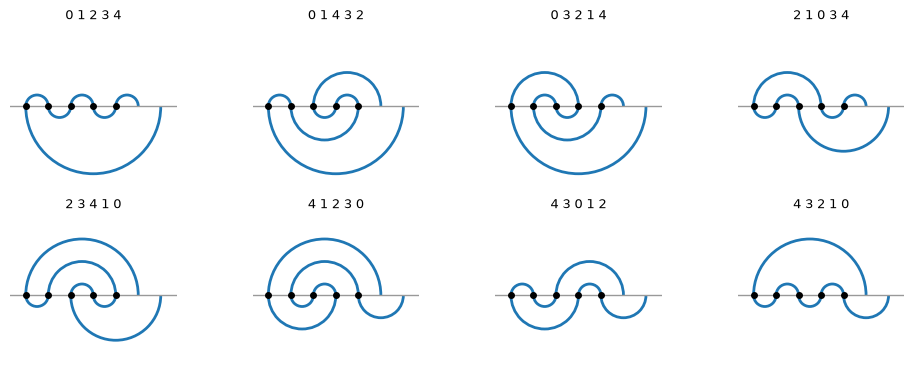

In [27]:
import matplotlib.pyplot as plt
from matplotlib.patches import Arc


def draw(ax, sigma):
    """Draw the meander with crossing order sigma on the axes ax."""
    P = path(sigma)
    n = len(sigma)
    ax.plot([-0.7, n + 1.7], [0, 0], color="0.6", lw=1)
    for k, (a, b) in enumerate(zip(P, P[1:])):
        lower = k % 2 == 0
        ax.add_patch(Arc(((a + b) / 2, 0), abs(b - a), abs(b - a),
                         theta1=180 if lower else 0, theta2=360 if lower else 180,
                         color="tab:blue", lw=2))
    ax.plot(range(n), [0] * n, "o", color="black", ms=4)
    ax.set_xlim(-0.7, n + 1.7)
    ax.set_ylim(-(n + 2) / 2, (n + 2) / 2)
    ax.set_aspect("equal")
    ax.axis("off")
    ax.set_title(" ".join(map(str, sigma)), fontsize=9)


rivers = [s for s in itertools.permutations(range(5)) if is_meander(s)]
fig, axes = plt.subplots(2, 4, figsize=(12, 4.5))
for ax, sigma in zip(axes.flat, rivers):
    draw(ax, sigma)
plt.show()

### How fast do the numbers grow?

The OEIS lists the values up to $n = 55$. Every value we computed matches.

In [28]:
OEIS_VALUES = [
    1, 1, 1, 2, 3, 8, 14, 42, 81, 262, 538, 1828, 3926, 13820, 30694, 110954, 252939, 933458,
    2172830, 8152860, 19304190, 73424650, 176343390, 678390116, 1649008456, 6405031050,
    15730575554, 61606881612, 152663683494, 602188541928, 1503962954930, 5969806669034,
    15012865733351, 59923200729046, 151622652413194, 608188709574124, 1547365078534578,
    6234277838531806, 15939972379349178, 64477712119584604, 165597452660771610,
    672265814872772972, 1733609081727968492, 7060941974458061392, 18276178714484582264,
    74661728661167809752, 193909492888406631692, 794337831754570367812, 2069504277256274074724,
    8499066628515413229282, 22206891674746169557410, 91412898898828176826244,
    239489513356610743216954, 987975910996038555989486, 2594805632585289523975474,
    10726008363361842734385644
]

assert values == OEIS_VALUES[:len(values)]

Odd and even $n$ behave differently, so compare each value with the one two steps back. The
square root of $a(n+2)/a(n)$ estimates the growth factor per crossing. It creeps up slowly:
even at $n = 53$ it is below 3.3, because the counts carry a power-law correction that fades
only as $n$ grows. Iwan Jensen's transfer-matrix enumeration (2000) estimated the growth constant of
closed meanders, per pair of crossings, as $12.2629$; its square root, $3.5018$, is drawn as the
dashed line. `ax.semilogy` plots with a logarithmic vertical axis, `ax.axhline` draws a
horizontal line, and `set_xlabel` labels an axis. Dividing two integers with `/` gives a float,
and `** 0.5` is a square root.

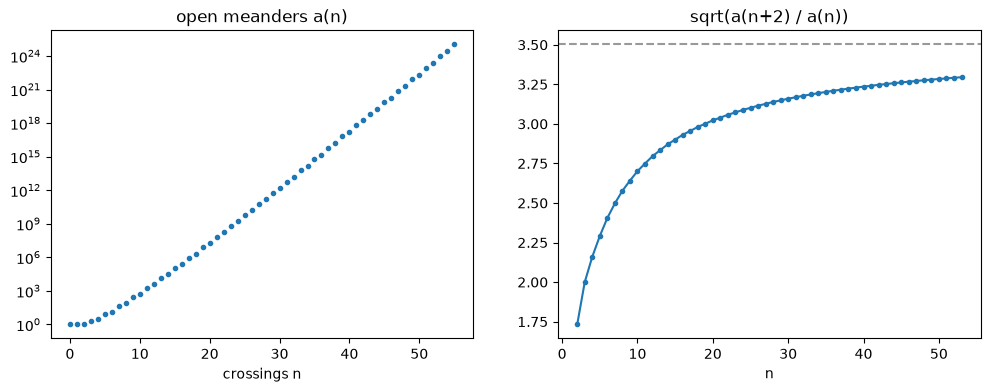

sqrt(a(55)/a(53)) = 3.2949


In [29]:
ns = range(2, 54)
ratios = [(OEIS_VALUES[n + 2] / OEIS_VALUES[n]) ** 0.5 for n in ns]
fig, (left, right) = plt.subplots(1, 2, figsize=(12, 4))
left.semilogy(range(len(OEIS_VALUES)), OEIS_VALUES, ".")
left.set_xlabel("crossings n")
left.set_title("open meanders a(n)")
right.plot(ns, ratios, ".-")
right.axhline(3.5018, color="0.6", ls="--")
right.set_xlabel("n")
right.set_title("sqrt(a(n+2) / a(n))")
plt.show()
print(f"sqrt(a(55)/a(53)) = {ratios[-1]:.4f}")

### Testing the meander exponent

Di Francesco, Golinelli and Guitter conjectured that the number $M_n$ of closed meanders of
order $n$ grows like $C A^n n^{-\alpha}$ with
$$\alpha = \frac{29 + \sqrt{145}}{12} \approx 3.4201,$$
an exponent from the physics of random surfaces. Borga, Gwynne and Sun (*Permutons, meanders,
and SLE-decorated Liouville quantum gravity*, J. Eur. Math. Soc., 2026) conjecture the matching
picture for random meanders: a Liouville quantum gravity surface carrying two independent
space-filling SLE$_8$ curves, one for the road and one for the river. Their *meandric
permutation* is our closed-meander crossing order, read the other way round.

Exact counts test the exponent. Section 5 checked that a closed meander of order $n$ is an open
meander with $2n - 1$ crossings, so $M_n$ is `OEIS_VALUES[2 * n - 1]`. If
$M_n \approx C A^n n^{-\alpha}$, then $M_{n+1}/M_n \approx A (1 + 1/n)^{-\alpha}$, so with
Jensen and Guttmann's estimate $A \approx 12.2629$,
$$\alpha_n = -\frac{\log\bigl(M_{n+1} / (A M_n)\bigr)}{\log(1 + 1/n)}$$
estimates $\alpha$ with an error of order $1/n$. Extrapolating linearly in $1/n$ from
$\alpha_{n-2}$ and $\alpha_n$ removes most of that error. `math.log` is the natural logarithm and
`math.sqrt` the square root.

In [30]:
A = 12.262874
ALPHA = (29 + math.sqrt(145)) / 12


def closed(n):
    return OEIS_VALUES[2 * n - 1]


def alpha_estimate(n):
    return -math.log(closed(n + 1) / (A * closed(n))) / math.log(1 + 1 / n)


print(" n   alpha_n   extrapolated")
for n in range(12, 27, 2):
    a0, a1 = alpha_estimate(n - 2), alpha_estimate(n)
    extrapolated = a1 - (a1 - a0) / (1 / n - 1 / (n - 2)) / n
    print(f"{n:2}   {a1:.4f}    {extrapolated:.4f}")
print(f"conjecture      {ALPHA:.4f}")

 n   alpha_n   extrapolated
12   3.2665    3.4053
14   3.2870    3.4100
16   3.3027    3.4129
18   3.3152    3.4149
20   3.3253    3.4163
22   3.3337    3.4172
24   3.3407    3.4180
26   3.3467    3.4185
conjecture      3.4201


The extrapolated estimates rise steadily towards $3.4201$: numerical support for the
conjecture, given the estimate of $A$, and no proof.

## 10. Index of Python features

Each feature is explained in the section listed, before its first use.

| Feature | Section |
|---|---|
| statements, expressions, `#` comments | 1 |
| integers of any size, `**`, `//`, `%`, `/` | 1 |
| variables, tuples, unpacking, `print`, f-strings | 1 |
| `bool`, `True`, `False`, `==`, `!=`, `and`, `or`, `not`, `True` as `1` | 1 |
| `def`, `return`, indentation, docstrings | 2 |
| chained comparisons, `!=` as exclusive or, `min`, `max` | 2 |
| lists, indexing, `len`, `range` | 2 |
| generator expressions, `all` | 2 |
| `*s` unpacking in a list | 3 |
| `import`, modules, `itertools.permutations` | 3 |
| `sum` of truth values | 3 |
| list comprehensions | 3 |
| `assert` | 4 |
| `for` loops, `range(a, b)`, `math.factorial`, `tuple` | 4 |
| constants in capitals, slices `s[a:b]` | 4 |
| `(0, *rest)`, `%` for wrapping round | 5 |
| sets, set comprehensions, `set`, tuple `+`, one-element tuples `(x,)` | 5 |
| nested functions, closures, `nonlocal`, recursion | 6 |
| `append`, `pop`, `add`, `remove`, `sorted`, conditional expressions | 6 |
| `if`, `elif`, `else`, default arguments, returning tuples | 6 |
| empty collections are false | 6 |
| `time.perf_counter`, format specifications `{x:,}`, `{x:.1f}` | 6 |
| strings: indexing, slicing, `+`, `list(word)`, `"".join`, `del` | 7 |
| `while`, `+=` | 7 |
| generators and `yield` | 7 |
| dictionaries, `get`, `items`, `defaultdict`, `from … import` | 7 |
| `pass`, `enumerate`, negative indices | 7 |
| the global interpreter lock, processes, pickling | 8 |
| `zlib.crc32`, `encode`, why not `hash` | 8 |
| `_` as a name | 8 |
| `ProcessPoolExecutor`, `pool.map`, `with`, fork, `os.cpu_count` | 8 |
| `zip(*rows)` | 8 |
| `import … as`, Matplotlib, `plt.subplots`, `Arc`, `add_patch`, `axes.flat` | 9 |
| `zip`, `map`, `" ".join`, `[0] * n` | 9 |
| `semilogy`, `axhline`, `** 0.5` | 9 |
| `math.log`, `math.sqrt` | 9 |